# Agentic Wi-Fi Spatial Attribution — **Autonomous Colab Demo**

**Notebook 1 of 2.** This notebook is *fully self-contained*: it defines a
compact version of the platform's Bayesian localisation + attribution pipeline
**inline** (no repository checkout, only NumPy/SciPy/Matplotlib, which Colab
already provides). Run it top to bottom.

It demonstrates, for a single Wi-Fi incident in a synthetic critical-
infrastructure floor:

1. an RSSI log-distance **radiomap** and an FTM/RTT **pseudo-range** model,
2. **robust Bayesian fusion** into a normalised spatial posterior,
3. **uncertainty** (HPD region, entropy) and **per-zone** probabilities,
4. a **rogue-AP** attack injected via a digital twin, detected by the
   twin residual, and
5. a hash-anchored **Spatial Attribution Record (SAR)**.

> ⚠️ Synthetic data only — no real coordinates or CII configurations.
> No performance advantage is claimed; this is a reference/teaching artefact.

## 0. Setup (dependencies are pre-installed on Colab)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t
from scipy.special import logsumexp
import hashlib, json

np.set_printoptions(suppress=True)
print("NumPy", np.__version__)

NumPy 2.4.6


## 1. Synthetic site, zones and sensors

A fictional 40 x 25 m single floor with three security zones (public,
controlled, critical) and eight ceiling sensors; four are FTM anchors.

In [2]:
GRID = dict(x0=0, x1=40, y0=0, y1=25, res=0.5)
ZONES = [("public", 0, 0, 14, 25), ("controlled", 14, 0, 28, 25),
         ("critical", 28, 0, 40, 25)]
# sensor: (id, x, y, is_ftm)
SENSORS = [("S1",3,3,True),("S2",3,22,True),("S3",12,12,False),("S4",20,3,True),
           ("S5",20,22,True),("S6",30,12,True),("S7",37,3,False),("S8",37,22,True)]

xs = GRID["x0"] + (np.arange((GRID["x1"]-GRID["x0"])/GRID["res"]) + 0.5)*GRID["res"]
ys = GRID["y0"] + (np.arange((GRID["y1"]-GRID["y0"])/GRID["res"]) + 0.5)*GRID["res"]
GX, GY = np.meshgrid(xs, ys)
CX, CY = GX.ravel(), GY.ravel()
NCELL = CX.size
CELL_AREA = GRID["res"]**2
print("grid cells:", NCELL, " cell area:", CELL_AREA, "m^2")

grid cells: 4000  cell area: 0.25 m^2


## 2. Physical models

**Path loss** (mean RSSI): `RSSI(d) = P0 - 10 n log10(d/d0) + noise`.
**FTM** pseudo-range: `d = c * RTT / 2`.

In [3]:
C_LIGHT = 299_792_458.0
P0, D0, PLE, RSSI_FLOOR = -40.0, 1.0, 2.8, -95.0
SIGMA_RSSI, T_DOF = 4.0, 4.0
SIGMA_LOS, SIGMA_NLOS, NLOS_BIAS, NLOS_P = 1.0, 4.0, 3.0, 0.25

def mean_rssi(d):
    d = np.maximum(d, 1e-3)
    return np.maximum(P0 - 10*PLE*np.log10(d/D0), RSSI_FLOOR)

def dist(px, py):
    return np.hypot(CX - px, CY - py)

# Immutable baseline radiomap: predicted mean RSSI from each sensor to each cell
RADIOMAP = {sid: mean_rssi(dist(x, y)) for sid, x, y, _ in SENSORS}
print("radiomap built for", len(RADIOMAP), "sensors")

radiomap built for 8 sensors


## 3. Digital twin: synthesise an incident (with an injected rogue AP)

The true source sits in the **critical** zone. A rogue AP is injected at (10,20)
in the public area, boosting nearby sensors above the baseline prediction.

In [4]:
rng = np.random.default_rng(777)
TRUE = np.array([33.0, 12.0])          # ground truth (synthetic)
ROGUE = np.array([10.0, 20.0])

def sample_incident(true_xy, rogue=None, drop_ftm=False):
    rssi, rtt = {}, {}
    for sid, x, y, is_ftm in SENSORS:
        d = float(np.hypot(true_xy[0]-x, true_xy[1]-y))
        rssi[sid] = float(mean_rssi(np.array([d]))[0] + rng.normal(0, 3.0))
        if is_ftm and not drop_ftm:
            rtt[sid] = 2.0*max(d + rng.normal(0,1.0), 0.1)/C_LIGHT
    if rogue is not None:
        for sid, x, y, _ in SENSORS:
            dr = float(np.hypot(rogue[0]-x, rogue[1]-y))
            rssi[sid] = max(rssi[sid], float(mean_rssi(np.array([dr]))[0]) + 8.0)
    return rssi, rtt

rssi_obs, rtt_obs = sample_incident(TRUE, rogue=ROGUE)
print("RSSI (dBm):", {k: round(v,1) for k,v in rssi_obs.items()})
print("FTM anchors:", list(rtt_obs))

RSSI (dBm): {'S1': -67.4, 'S2': -56.1, 'S3': -57.7, 'S4': -68.3, 'S5': -60.2, 'S6': -54.6, 'S7': -68.9, 'S8': -68.6}
FTM anchors: ['S1', 'S2', 'S4', 'S5', 'S6', 'S8']


## 4. Robust Bayesian fusion

RSSI uses a **Student-t** likelihood (robust to outliers); FTM uses a
**LOS/NLOS mixture**. Missing modalities simply drop out (neutral).

In [5]:
def rssi_loglik(obs):
    ll = np.zeros(NCELL)
    for sid, r in obs.items():
        mu = RADIOMAP[sid]
        resid = (r - mu)/SIGMA_RSSI
        ll += student_t.logpdf(resid, df=T_DOF) - np.log(SIGMA_RSSI)
    return ll

def ftm_loglik(obs):
    ll = np.zeros(NCELL)
    sens = {sid:(x,y) for sid,x,y,_ in SENSORS}
    for sid, rtt in obs.items():
        rng_m = C_LIGHT*rtt/2.0
        x,y = sens[sid]; td = np.hypot(CX-x, CY-y)
        los  = -0.5*((rng_m-td)/SIGMA_LOS)**2 - np.log(SIGMA_LOS*np.sqrt(2*np.pi))
        nlos = -0.5*((rng_m-(td+NLOS_BIAS))/SIGMA_NLOS)**2 - np.log(SIGMA_NLOS*np.sqrt(2*np.pi))
        ll += np.logaddexp(np.log1p(-NLOS_P)+los, np.log(NLOS_P)+nlos)
    return ll

def fuse(*logliks):
    u = np.zeros(NCELL)
    for ll in logliks:
        if ll is not None: u = u + ll
    u -= u.max()
    p = np.exp(u - logsumexp(u)); p = np.maximum(p,0)
    return p/p.sum()

post = fuse(rssi_loglik(rssi_obs), ftm_loglik(rtt_obs))
print("posterior sums to 1:", np.isclose(post.sum(), 1.0))

posterior sums to 1: True


## 5. Uncertainty, HPD region and zone probabilities

In [6]:
def map_xy(p):
    i = int(np.argmax(p)); return np.array([CX[i], CY[i]])
def entropy(p):
    q = p[p>0]; return float(-np.sum(q*np.log(q)))
def hpd_mask(p, mass=0.95):
    o = np.argsort(p)[::-1]; cum = np.cumsum(p[o])
    k = int(np.searchsorted(cum, mass)+1); m = np.zeros(p.size, bool); m[o[:k]] = True
    return m
def zone_post(p):
    out = {}; assigned = np.zeros(NCELL, bool)
    for name,x0,y0,x1,y1 in ZONES:
        m = (CX>=x0)&(CX<x1)&(CY>=y0)&(CY<y1); out[name]=float(p[m].sum()); assigned|=m
    return out

m = map_xy(post); mask = hpd_mask(post)
print("MAP coordinate      :", np.round(m,2))
print("localisation error  : %.2f m" % np.linalg.norm(m-TRUE))
print("HPD area (95%%)      : %.1f m^2" % (mask.sum()*CELL_AREA))
print("entropy (nats)      : %.3f" % entropy(post))
print("zone posterior      :", {k:round(v,3) for k,v in zone_post(post).items()})

MAP coordinate      : [31.75 13.75]
localisation error  : 2.15 m
HPD area (95%)      : 10.5 m^2
entropy (nats)      : 3.554
zone posterior      : {'public': 0.0, 'controlled': 0.003, 'critical': 0.997}


## 6. Visualise the posterior, zones, sensors, MAP and HPD

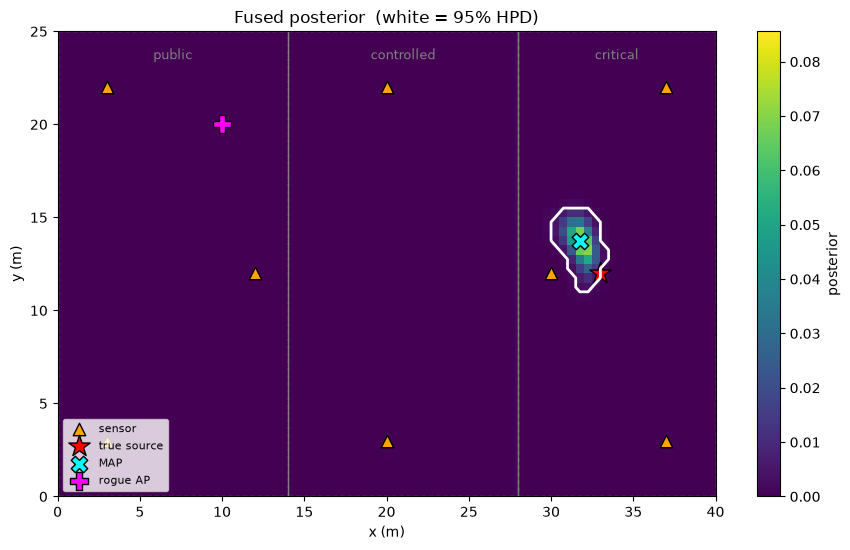

In [7]:
fig, ax = plt.subplots(figsize=(9,5.6))
img = post.reshape(GY.shape)
pc = ax.pcolormesh(GX, GY, img, shading="auto", cmap="viridis")
ax.contour(GX, GY, mask.reshape(GY.shape).astype(float), levels=[0.5],
           colors="white", linewidths=2)
for name,x0,y0,x1,y1 in ZONES:
    ax.plot([x0,x1,x1,x0,x0],[y0,y0,y1,y1,y0], color="grey", ls="--", lw=1)
    ax.text((x0+x1)/2, y1-1.5, name, color="grey", ha="center", fontsize=9)
sx=[s[1] for s in SENSORS]; sy=[s[2] for s in SENSORS]
ax.scatter(sx, sy, marker="^", c="orange", s=80, edgecolor="k", label="sensor")
ax.scatter(*TRUE, marker="*", c="red", s=260, edgecolor="k", label="true source")
ax.scatter(*m, marker="X", c="cyan", s=140, edgecolor="k", label="MAP")
ax.scatter(*ROGUE, marker="P", c="magenta", s=160, edgecolor="k", label="rogue AP")
ax.set_title("Fused posterior  (white = 95% HPD)"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.legend(loc="lower left", fontsize=8); plt.colorbar(pc, ax=ax, label="posterior")
plt.tight_layout(); plt.show()

## 7. Twin residual → threat, and a Spatial Attribution Record (SAR)

The **digital-twin residual** compares the measured RSSI to what the baseline
radiomap predicts at the MAP location. A large residual flags a domain shift /
possible manipulation — here, the injected rogue AP.

In [8]:
pred_at_map = {sid: float(mean_rssi(np.array([np.hypot(m[0]-x, m[1]-y)]))[0])
               for sid,x,y,_ in SENSORS}
resid = np.sqrt(np.mean([(rssi_obs[s]-pred_at_map[s])**2 for s in rssi_obs]))
anomaly = min(1.0, resid/15.0)
level = "high" if anomaly>=0.7 else "medium" if anomaly>=0.4 else "low" if anomaly>=0.15 else "none"
tier = "HUMAN_IN_THE_LOOP" if anomaly>=0.7 else "VERIFY" if anomaly>=0.4 else "OBSERVE"
print("twin residual: %.2f dB -> anomaly=%.2f level=%s -> SOC tier=%s" % (resid, anomaly, level, tier))

sar = {
  "incident_id": "INC-AUTONOMOUS-0001", "site_id": "SITE-DEMO-001",
  "map_crs": "local-metric-synthetic", "MAP": [round(float(v),3) for v in m],
  "zone_posterior": {k: round(v,4) for k,v in zone_post(post).items()},
  "HPD_mass": 0.95, "HPD_area_m2": round(float(mask.sum()*CELL_AREA),3),
  "entropy_nats": round(entropy(post),4),
  "threat_state": {"level": level, "anomaly_score": round(float(anomaly),3),
                   "twin_residual_db": round(float(resid),3)},
  "recommended_action": tier,
  "model_version": "awa-autonomous-0.1.0",
}
sar["provenance_hash"] = hashlib.sha256(
    json.dumps(sar, sort_keys=True, separators=(",",":")).encode()).hexdigest()
print(json.dumps(sar, indent=2))

twin residual: 13.12 dB -> anomaly=0.87 level=high -> SOC tier=HUMAN_IN_THE_LOOP
{
  "incident_id": "INC-AUTONOMOUS-0001",
  "site_id": "SITE-DEMO-001",
  "map_crs": "local-metric-synthetic",
  "MAP": [
    31.75,
    13.75
  ],
  "zone_posterior": {
    "public": 0.0,
    "controlled": 0.0027,
    "critical": 0.9973
  },
  "HPD_mass": 0.95,
  "HPD_area_m2": 10.5,
  "entropy_nats": 3.5541,
  "threat_state": {
    "level": "high",
    "anomaly_score": 0.875,
    "twin_residual_db": 13.123
  },
  "recommended_action": "HUMAN_IN_THE_LOOP",
  "model_version": "awa-autonomous-0.1.0",
  "provenance_hash": "b517749bc8110096b0ab151462e3567ca90615f6df83e52db5be7ccf1e073c84"
}


## 8. Sanity check: a missing modality must *widen*, not zero, the posterior

Invariant (prompt Module 22): dropping FTM increases the HPD area and never
produces NaNs.

In [9]:
rssi2, rtt2 = sample_incident(TRUE, rogue=None, drop_ftm=True)
post_rssi_only = fuse(rssi_loglik(rssi2), None)
post_both      = fuse(rssi_loglik(rssi2), ftm_loglik(sample_incident(TRUE)[1]))
a_missing = hpd_mask(post_rssi_only).sum()*CELL_AREA
a_both    = hpd_mask(post_both).sum()*CELL_AREA
print("HPD area  RSSI-only : %.1f m^2" % a_missing)
print("HPD area  RSSI+FTM  : %.1f m^2" % a_both)
print("missing modality widened the posterior:", a_missing >= a_both)
assert np.isfinite(post_rssi_only).all()

HPD area  RSSI-only : 112.5 m^2
HPD area  RSSI+FTM  : 7.5 m^2
missing modality widened the posterior: True


## Summary

This autonomous notebook reproduced the full inference-and-attribution loop from
scratch: radiomap → robust fusion → uncertainty/zones/HPD → twin-residual threat
detection → hash-anchored SAR, plus a missing-modality invariant check.

For richer, package-based computations and visualisations (calibration curves,
error CDFs, adversarial-scenario comparison, readiness gating), see
**Notebook 2 — `02_computed_visualizations.ipynb`**.